In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\1_comp
scenario=1comp  K_MODEL=5  K_TRUE=1
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full, unbounded  +  Chebyshev-filtered) ──────────
# Two grids are built per parameter and carried through every cell below. Neither
# uses the True DGP to set bounds beyond including it in the envelope/moments -
# it stays an overlay only.
#   "Full"                   - mc.build_grids_full: raw min/max envelope over EVERY
#                               component (all K, incl. surplus/empty ones) of every
#                               sampler and the True DGP. Nothing is excluded, so every
#                               metric integrates over the ENTIRE marginal - but a
#                               diffuse empty component (K_MODEL > K_TRUE) or a sampler
#                               exploring far off the high-density area can stretch this
#                               range enormously and squash the real mass into a few
#                               pixels.
#   "Chebyshev (k=5, >=96%)" - mc.build_grids_chebyshev: clipped to each model's own
#                               AGGREGATE mixture [mean - 5*std, mean + 5*std] (Eq.
#                               5.5.2). Chebyshev's inequality, P(|X-mean|>=k*std) <=
#                               1/k**2, holds for ANY distribution with finite variance
#                               (no normality/unimodality assumption - the invariant
#                               marginal is itself a mixture) - so >=1 - 1/5**2 = 96% of
#                               each model's own marginal mass is guaranteed to lie
#                               inside its window, trimming the outlier-driven tails of
#                               "Full" while keeping a distribution-free coverage bound.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-2300.97, +1463.81]
  Alt2       [-739.71, +574.15]
  Alt3       [-453.70, +432.59]
  Price      [-236.99, +267.19]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-14.05, +16.61]
  Alt2       [-8.85, +16.64]
  Alt3       [-6.35, +12.28]
  Price      [-10.42, +5.30]


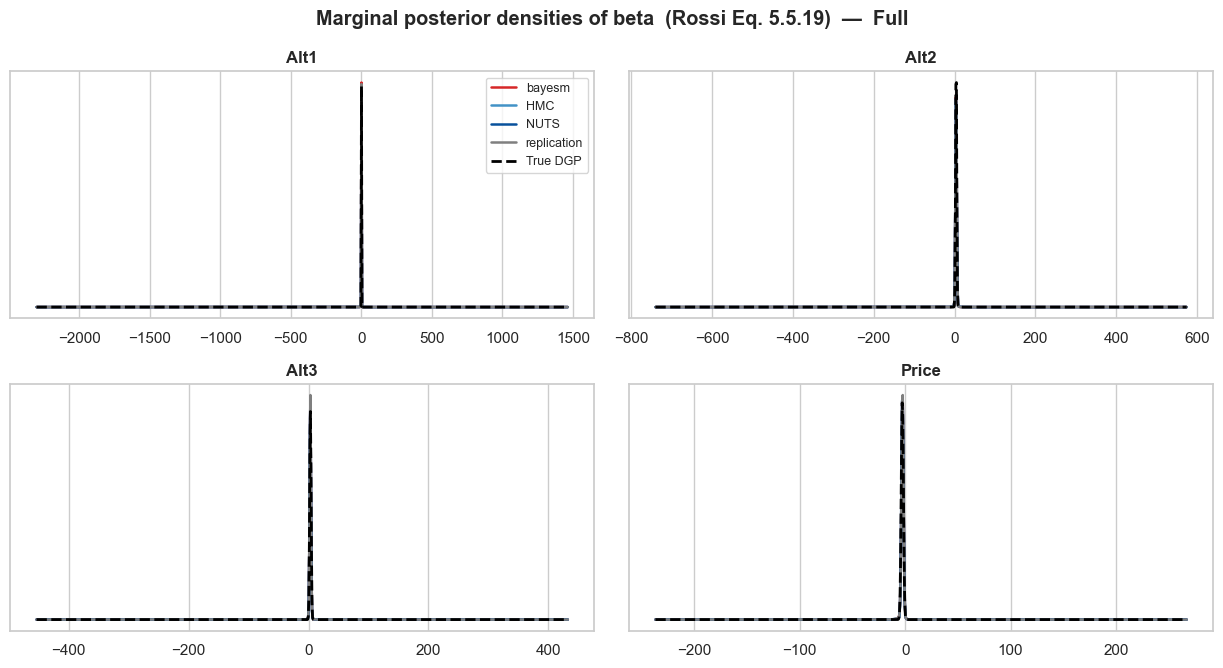

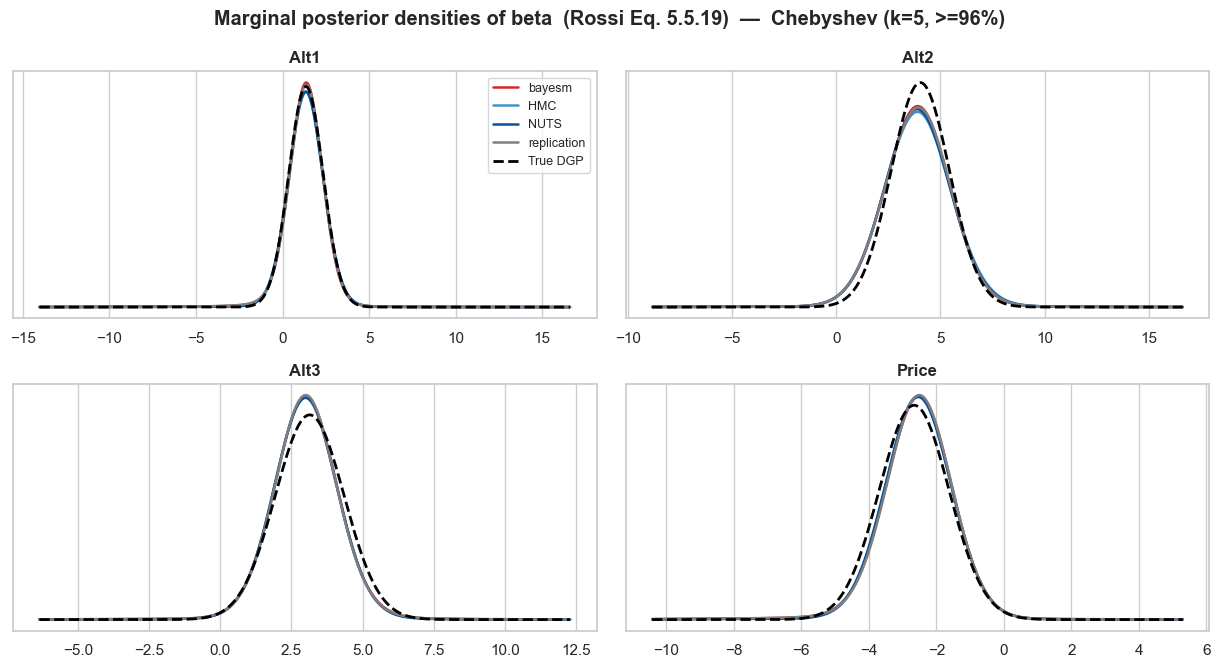

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev-filtered ──────────
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light). One figure per grid pass.
# `marginal_density` is O(R*K*n_grid) per model - computed ONCE per (model, grid)
# pass here and cached in DENS/DENS_TRUE so Cells 5 and 7 reuse it instead of
# recomputing it internally.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  \u2014  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev-filtered ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them. The two passes differ only in the integration grid built in Cell 3;
# distances typically shrink under "Chebyshev" once the diffuse/outlier tails that
# dominate "Full" are clipped out. Reuses the densities cached in Cell 4 (DENS,
# DENS_TRUE) rather than recomputing marginal_density a second time.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:222: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06482      inf  0.00357  0.01517       0.07532
            Alt2     0.08373  0.12270  0.00636  0.06804       0.22674
            Alt3     0.07656      inf  0.00507  0.06219       0.17614
            Price    0.08796      inf  0.00639  0.06057       0.16857
HMC         Alt1     0.07530      inf  0.00430  0.01607       0.17764
            Alt2     0.09795  0.40236  0.00852  0.07892       0.30657
            Alt3     0.08479      inf  0.00606  0.06412       0.20246
            Price    0.09143      inf  0.00672  0.05849       0.19245
NUTS        Alt1     0.06717      inf  0.00347  0.01347       0.14954
            Alt2     0.09807  0.58325  0.00832  0.07591       0.32635
            Alt3     0.08666      inf  0.00623  0.06309       0.22657
            Price    0.08770      inf  0.00610  0.05346       0.18877
replication Alt1     0.06874      inf  0.00402  0.01670       0.08140
            Alt2     0.08537  0.13805  0.00658  0.06849       0.22982
            Alt3     0.07896      inf  0.00543  0.06392       0.17031
            Price    0.09661      inf  0.00760  0.06446       0.18643

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.07246  0.15696  0.00411  0.02295       0.06993
            Alt2     0.08137  0.05989  0.00609  0.06569       0.21232
            Alt3     0.07034  0.04747  0.00444  0.05952       0.15192
            Price    0.07907  0.07147  0.00536  0.06059       0.13808
HMC         Alt1     0.07493  0.30207  0.00418  0.01968       0.09542
            Alt2     0.09123  0.07970  0.00764  0.07638       0.23549
            Alt3     0.07417  0.05520  0.00489  0.06097       0.15187
            Price    0.07552  0.07106  0.00488  0.05714       0.13772
NUTS        Alt1     0.06778  0.24440  0.00346  0.01863       0.08550
            Alt2     0.08815  0.08379  0.00704  0.07199       0.23060
            Alt3     0.07199  0.05470  0.00462  0.05944       0.15125
            Price    0.07057  0.06490  0.00422  0.05206       0.12720
replication Alt1     0.07646  0.16398  0.00457  0.02258       0.07320
            Alt2     0.08269  0.06220  0.00627  0.06582       0.20965
            Alt3     0.07332  0.04948  0.00484  0.06140       0.14816
            Price    0.08418  0.08585  0.00604  0.06387       0.14460

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent - computed analytically from the draws, not by integrating over
# either grid - so this runs once for both passes above.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.301,1.227,1.279,1.302,1.349
Alt2,3.866,3.884,3.896,3.886,4.032
Alt3,2.989,2.991,2.968,2.999,3.141
Price,-2.565,-2.562,-2.561,-2.591,-2.659


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.626,6.676,9.396,1.653,0.980
Alt2,3.039,5.582,6.497,3.141,1.974
Alt3,1.925,2.649,3.471,1.892,1.454
Price,1.788,2.283,2.471,2.017,1.063


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series - Full vs Chebyshev-filtered ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter. The density mask
# (density_threshold) is relative to each grid's own peak, so both passes restrict to
# their own high-density region even though "Full" spans a much wider range. Reuses
# the densities cached in Cell 4 (DENS) rather than recomputing marginal_density a
# third time just to rebuild the mask.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for label, grids in GRIDS.items():
    print(f"=== Grid: {label} ===")
    for m in models:
        print(f"--- {m['name']} ---")
        display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40,
                                               marg=DENS[label][m["name"]]).round(3))

NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a
      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).
      It cannot detect multimodality a lone chain never explored - the
      between-chain R-hat comes from the 2-chain runs.

=== Grid: Full ===
--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,1,3421.601,3421.601,1.001,1.001
Alt2,1,1138.836,1138.836,1.000,1.000
Alt3,1,657.836,657.836,1.001,1.001
Price,1,268.143,268.143,1.004,1.004


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,2,101.906,238.729,1.021,1.014
Alt2,1,61.717,61.717,1.049,1.049
Alt3,1,198.972,198.972,1.023,1.023
Price,1,134.563,134.563,1.022,1.022


--- NUTS ---


...

,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,8,78.622,110.925,1.028,1.016
Alt2,16,58.233,117.840,1.050,1.028
Alt3,15,47.192,108.102,1.049,1.032
Price,16,108.059,321.311,1.023,1.013


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,8,199.130,437.545,1.016,1.007
Alt2,16,223.144,692.294,1.017,1.005
Alt3,15,231.039,595.271,1.018,1.005
Price,16,228.914,711.845,1.016,1.007


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,9,108.111,271.674,1.026,1.011
Alt2,16,161.033,538.445,1.010,1.005
Alt3,16,96.053,339.423,1.014,1.006
Price,17,98.286,715.145,1.025,1.004


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
# Grid-independent, like Cell 6 - runs once.
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - Two grids are compared throughout: 'Full' (unbounded envelope over every")
print("   component of every sampler + True DGP - nothing excluded, but can be very")
print("   wide when a sampler explores far off the high-density area or K_MODEL >")
print("   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate")
print("   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%")
print("   of that model's own marginal mass is retained, regardless of shape).")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                   
Alt1  Mean     698.7748  1.0004
      Var      658.3526  1.0029
Alt2  Mean     534.2830  1.0047
      Var     1048.1906  1.0018
Alt3  Mean     527.0809  1.0009
      Var      640.3593  1.0025
Price Mean     224.3346  1.0063
      Var      291.4794  1.0015

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean      7.8656  1.1859
      Var      14.5526  1.1013
Alt2  Mean     73.5157  1.0371
      Var     306.8719  1.0070
Alt3  Mean     83.2072  1.0134
      Var     326.2818  1.0045
Price Mean     81.9322  1.0112
      Var     214.4236  1.0039

--- NUTS ---


ESS    Rhat
param moment                  
Alt1  Mean    163.5408  1.0150
      Var     245.1174  1.0084
Alt2  Mean     34.2678  1.0534
      Var     175.6482  1.0187
Alt3  Mean    221.4079  1.0105
      Var     165.6833  1.0291
Price Mean     41.3870  1.0498
      Var     167.5809  1.0190

--- replication ---


ESS    Rhat
param moment                  
Alt1  Mean    372.8800  1.0046
      Var     466.9830  1.0024
Alt2  Mean    358.9903  1.0019
      Var     403.3850  1.0014
Alt3  Mean    393.6197  1.0033
      Var     407.3182  1.0033
Price Mean    263.4249  1.0017
      Var     169.1585  1.0010


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - Two grids are compared throughout: 'Full' (unbounded envelope over every
   component of every sampler + True DGP - nothing excluded, but can be very
   wide when a sampler explores far off the high-density area or K_MODEL >
   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate
   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%
   of that model's own marginal mass is retained, regardless of shape).
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   th